# Four-Pillar Evaluation of Synthetic Data

This notebook evaluates synthetic datasets across the four axes of the proposed framework:

| Pillar | Question | Metrics |
|--------|----------|--------|
| **Distribution** | Do individual features look statistically correct? | Mean KLD, Max KLD, Proportion significant |
| **Structure** | Are relationships between features preserved? | Correlation diff, PCA projection, Correlation heatmap |
| **Realism** | Do synthetic samples fall within the support of the real data? | NN distance (syn-to-real), support proximity score |
| **Utility** | Can the data still support downstream tasks? | TSTR F1, TRTR F1, Utility gap |

A synthetic dataset is not described by a single score, but by its position in this four-dimensional space.
Different methods may occupy similar regions along one axis while differing substantially along others.

**On copying.** The four pillars measure *quality*, not *novelty*. A method that resamples training rows (e.g. bootstrap) will score well on all axes, yet it offers no privacy or augmentation. Copying should be assessed separately â€” e.g. via duplicate-fraction audits or nearest-neighbour identity checks â€” and discussed as an independent failure mode.

---

## 1. Setup

In [35]:
%matplotlib inline

import sys
import pickle
import warnings
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from loaders import load_breast, load_diabetes, load_HIV
from models.bootstrap import sample_bootstrap
from models.gmm import sample_gmm
from models.cvae import train_cvae_on_arrays, sample_cvae_dataset
from models.iid_columnwise import sample_columnwise
from metrics import (
    stratified_subsample, kld_per_feature, correlation_diff,
    per_feature_tests, nn_distances, tstr_f1,
)
from plots import METHOD_COLORS, METHOD_ORDER, plot_corr_matrices, plot_pca_projection

warnings.filterwarnings('ignore')

SEED = 42
DATASETS = [load_HIV, load_breast, load_diabetes]
METHODS = ['bootstrap', 'gmm', 'cvae', 'iid_columnwise']
FRAC = 1.0
CVAE_EPOCHS = 200

FIGDIR = Path('../results/figures')
FIGDIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


## 2. Generate synthetic data

Generate one synthetic dataset per (dataset, method) at full sample size.
Store raw arrays for all downstream analyses.

In [36]:
def fraction_to_n(y, frac):
    n0 = max(2, int(np.floor((y == 0).sum() * frac)))
    n1 = max(2, int(np.floor((y == 1).sum() * frac)))
    return n0, n1


store = {}  # keyed by (dataset_name, method)

for load_fn in DATASETS:
    data = load_fn()
    ds = data['dataset']
    X, y = data['X'], data['y'].ravel().astype(int)
    fnames = data['feature_names']
    n0, n1 = fraction_to_n(y, FRAC)
    X_sub, y_sub, _ = stratified_subsample(X, y, n0=n0, n1=n1, seed=SEED)

    for method in METHODS:
        print(f'{ds} | {method} | n0={n0}, n1={n1}')

        if method == 'bootstrap':
            X_syn, y_syn = sample_bootstrap(X_sub, y_sub, n0, n1, seed=SEED)
        elif method == 'gmm':
            X_syn, y_syn = sample_gmm(X_sub, y_sub, n0, n1, seed=SEED)
        elif method == 'cvae':
            best = train_cvae_on_arrays(X_sub, y_sub, seed=SEED,
                                        epochs=CVAE_EPOCHS, batch_size=32)
            X_syn, y_syn = sample_cvae_dataset(best, n0, n1, seed=SEED)
        elif method == 'iid_columnwise':
            X_syn, y_syn = sample_columnwise(X_sub, y_sub, n0, n1, seed=SEED)

        store[(ds, method)] = {
            'X_real': X_sub, 'y_real': y_sub,
            'X_syn': X_syn, 'y_syn': y_syn,
            'feature_names': fnames,
        }

print(f'\nGenerated {len(store)} synthetic datasets.')

HIV | bootstrap | n0=23, n1=68
HIV | gmm | n0=23, n1=68
HIV | cvae | n0=23, n1=68
Epoch  50 | val loss=85.1894 recon=80.0592 kl=10.2603
Epoch 100 | val loss=76.9943 recon=71.1062 kl=11.7761
Epoch 150 | val loss=70.0899 recon=64.2805 kl=11.6186
Epoch 200 | val loss=67.3083 recon=61.3235 kl=11.9695
HIV | iid_columnwise | n0=23, n1=68
breast_cancer | bootstrap | n0=212, n1=357
breast_cancer | gmm | n0=212, n1=357
breast_cancer | cvae | n0=212, n1=357
Epoch  50 | val loss=9.8116 recon=6.5317 kl=6.5597
Epoch 100 | val loss=8.7094 recon=5.3509 kl=6.7171
Epoch 150 | val loss=9.0034 recon=5.6890 kl=6.6288
Epoch 200 | val loss=8.5376 recon=5.1160 kl=6.8433
breast_cancer | iid_columnwise | n0=212, n1=357
diabetes | bootstrap | n0=500, n1=268
diabetes | gmm | n0=500, n1=268
diabetes | cvae | n0=500, n1=268
Epoch  50 | val loss=3.9870 recon=2.0095 kl=3.9551
Epoch 100 | val loss=4.0325 recon=1.9900 kl=4.0849
Epoch 150 | val loss=4.0398 recon=1.9414 kl=4.1968
Epoch 200 | val loss=3.9937 recon=2.0983

## 3. Compute all pillar metrics

Build a tidy DataFrame with one row per (dataset, method) containing metrics from all four pillars.

In [37]:
rows = []

for (ds, method), d in store.items():
    X_r, y_r = d['X_real'], d['y_real']
    X_s, y_s = d['X_syn'], d['y_syn']

    # Distribution
    kld = kld_per_feature(X_r, X_s)
    pft = per_feature_tests(X_r, X_s)

    # Structure
    corr = correlation_diff(X_r, X_s)

    # Realism
    nn = nn_distances(X_r, X_s)

    # Utility
    util = tstr_f1(X_r, y_r, X_s, y_s, seed=SEED)

    rows.append({
        'dataset': ds,
        'method': method,
        # Distribution
        'kld_mean': kld['kld_mean'],
        'kld_max': kld['kld_max'],
        'prop_significant': pft['prop_significant'],
        # Structure
        'corr_diff': corr['corr_mean_abs_diff'],
        'corr_max_diff': corr['corr_max_abs_diff'],
        # Realism
        'nn_dist_mean': nn['nn_dist_mean'],
        'nn_dist_median': nn['nn_dist_median'],
        'nn_real_mean': nn['nn_real_mean'],
        'nn_ratio': nn['nn_ratio_mean'],
        # Utility
        'tstr_f1': util['tstr_f1'],
        'trtr_f1': util['trtr_f1'],
        'utility_gap': util['utility_gap'],
    })

df = pd.DataFrame(rows)
display(df)

,dataset,method,kld_mean,kld_max,prop_significant,corr_diff,corr_max_diff,nn_dist_mean,nn_dist_median,nn_real_mean,nn_ratio,tstr_f1,trtr_f1,utility_gap
0,HIV,bootstrap,0.756319,2.750576,0.000000,0.072019,0.346546,0.000041,0.000000,1711.817017,2.376276e-08,0.992701,0.964444,-0.028256
1,HIV,gmm,1.181901,3.989480,0.031746,0.079204,1.045520,2127.632209,1963.145386,1711.817017,1.242909e+00,0.985507,0.964444,-0.021063
2,HIV,cvae,2.752097,6.514591,0.317460,0.119985,0.621882,1611.648764,1576.612305,1711.817017,9.414843e-01,0.977444,0.964444,-0.012999
3,HIV,iid_columnwise,0.813577,2.752854,0.000000,0.295962,1.076596,2875.729128,2802.197850,1711.817017,1.679928e+00,0.985075,0.964444,-0.020630
4,breast_cancer,bootstrap,0.087536,0.173149,0.000000,0.028775,0.154365,0.000002,0.000000,30.394851,6.587003e-08,0.986034,0.969187,-0.016846
5,breast_cancer,gmm,0.275869,1.238169,0.000000,0.075630,0.611208,29.775881,16.458576,30.394851,9.796357e-01,0.954930,0.969187,0.014258
6,breast_cancer,cvae,0.343848,0.779090,0.166667,0.064644,0.251785,23.057094,15.687629,30.394851,7.585855e-01,0.973721,0.969187,-0.004533
7,breast_cancer,iid_columnwise,0.082996,0.263975,0.000000,0.199537,0.825734,124.584923,74.700828,30.394851,4.098883e+00,0.958678,0.969187,0.010510
8,diabetes,bootstrap,0.050567,0.143974,0.000000,0.023314,0.065745,0.000000,0.000000,14.359372,0.000000e+00,0.868217,0.609921,-0.258296
9,diabetes,gmm,0.454899,0.944447,0.125000,0.026617,0.087691,19.433947,16.746012,14.359372,1.353398e+00,0.622222,0.609921,-0.012301


---
## 4. Pillar 1 â€” Distribution

**Question:** Do individual feature distributions match?

Assessed via KL divergence per feature and proportion of features with statistically significant distributional differences (Mann-Whitney U, alpha=0.05).

In [38]:
dist_cols = ['dataset', 'method', 'kld_mean', 'kld_max', 'prop_significant']
display(df[dist_cols].style.format(precision=3).background_gradient(
    subset=['kld_mean', 'kld_max', 'prop_significant'], cmap='RdYlGn_r', axis=0
))

,dataset,method,kld_mean,kld_max,prop_significant
0,HIV,bootstrap,0.756,2.751,0.000
1,HIV,gmm,1.182,3.989,0.032
2,HIV,cvae,2.752,6.515,0.317
3,HIV,iid_columnwise,0.814,2.753,0.000
4,breast_cancer,bootstrap,0.088,0.173,0.000
5,breast_cancer,gmm,0.276,1.238,0.000
6,breast_cancer,cvae,0.344,0.779,0.167
7,breast_cancer,iid_columnwise,0.083,0.264,0.000
8,diabetes,bootstrap,0.051,0.144,0.000
9,diabetes,gmm,0.455,0.944,0.125


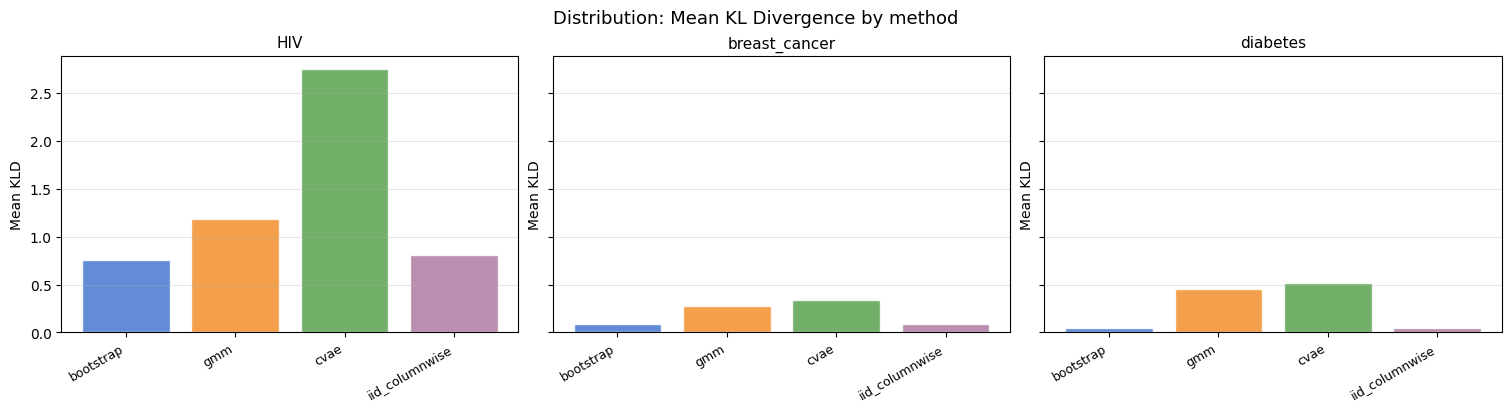

In [39]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5 * len(DATASETS), 4),
                          constrained_layout=True, sharey=True)

for ax, load_fn in zip(axes, DATASETS):
    ds = load_fn()['dataset']
    sub = df[df['dataset'] == ds]
    x = np.arange(len(METHODS))
    colors = [METHOD_COLORS.get(m, 'gray') for m in METHODS]
    vals = [sub[sub['method'] == m]['kld_mean'].values[0] for m in METHODS]
    ax.bar(x, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(METHODS, rotation=30, ha='right', fontsize=9)
    ax.set_title(ds, fontsize=11)
    ax.set_ylabel('Mean KLD')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribution: Mean KL Divergence by method', fontsize=13)
plt.show()

---
## 5. Pillar 2 â€” Structure

**Question:** Are relationships between features preserved?

Two layers of evidence are reported:

1. **Descriptive**: mean absolute correlation difference, correlation heatmaps, PCA projections. Useful for visual inspection â€” but pairwise linear correlations only capture a thin slice of joint structure. A method can match all `Corr(Xi, Xj)` and still get higher-order dependencies wrong (e.g. CVAE on these datasets, where ablation curves expose that the model isn't relying on the correct features).

2. **Radar score (Â§ 8)**: a **classifier two-sample test (C2ST)**. Train a Random Forest to discriminate real vs synthetic via 5-fold CV; map AUC to `1 - 2*|AUC - 0.5|`. AUC â‰ˆ 0.5 â‡’ joint distribution indistinguishable â‡’ score â‰ˆ 1. AUC â‰ˆ 1 â‡’ trivially separable â‡’ score â‰ˆ 0. The discriminator can use any feature combination, so it catches multivariate structure violations that the correlation table misses.

In [40]:
struct_cols = ['dataset', 'method', 'corr_diff', 'corr_max_diff']
display(df[struct_cols].style.format(precision=3).background_gradient(
    subset=['corr_diff', 'corr_max_diff'], cmap='RdYlGn_r', axis=0
))

,dataset,method,corr_diff,corr_max_diff
0,HIV,bootstrap,0.072,0.347
1,HIV,gmm,0.079,1.046
2,HIV,cvae,0.120,0.622
3,HIV,iid_columnwise,0.296,1.077
4,breast_cancer,bootstrap,0.029,0.154
5,breast_cancer,gmm,0.076,0.611
6,breast_cancer,cvae,0.065,0.252
7,breast_cancer,iid_columnwise,0.200,0.826
8,diabetes,bootstrap,0.023,0.066
9,diabetes,gmm,0.027,0.088


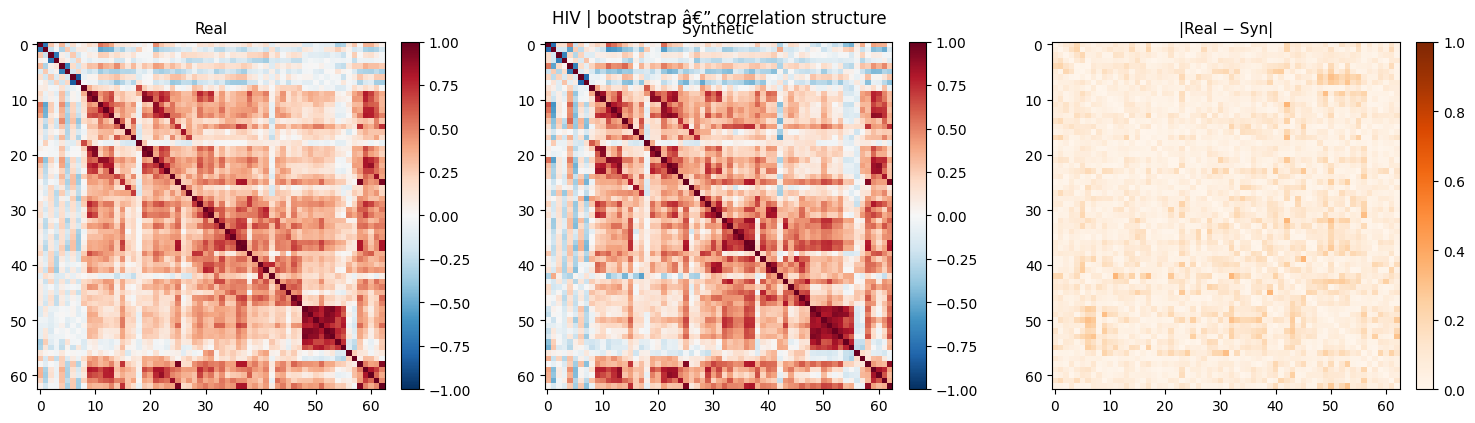

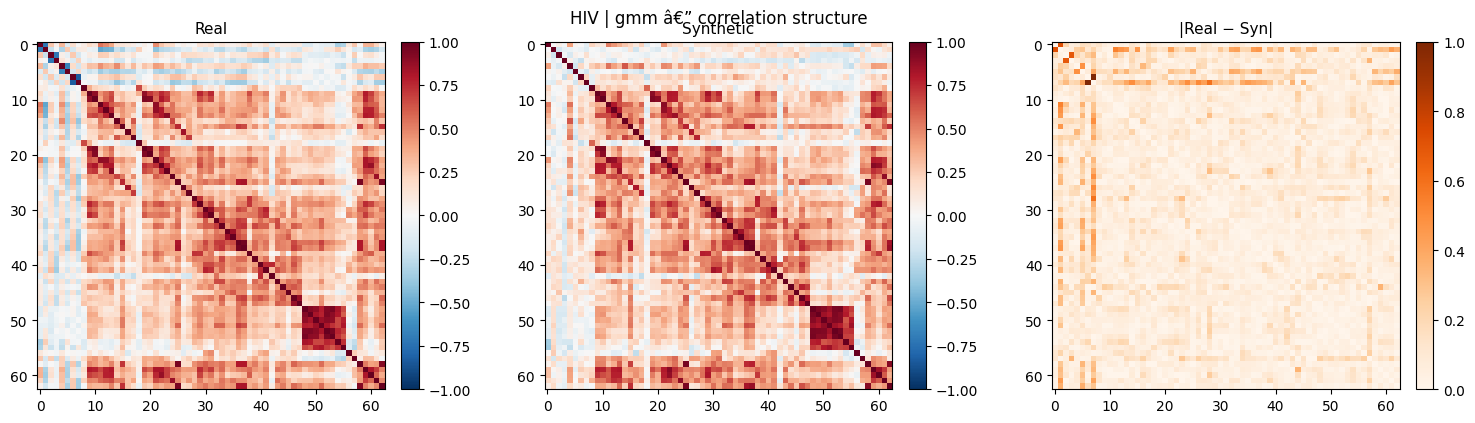

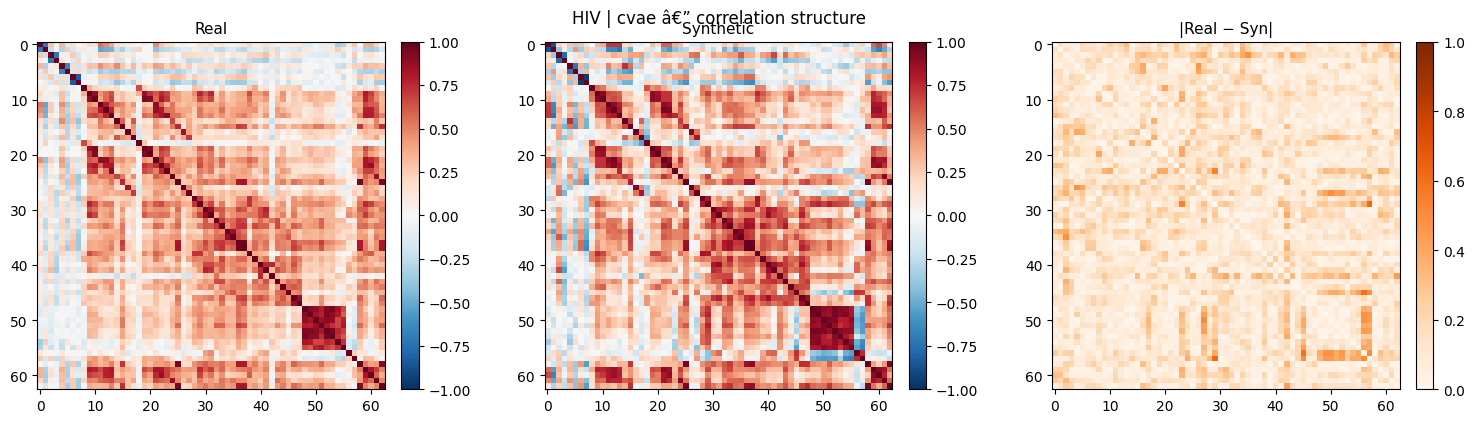

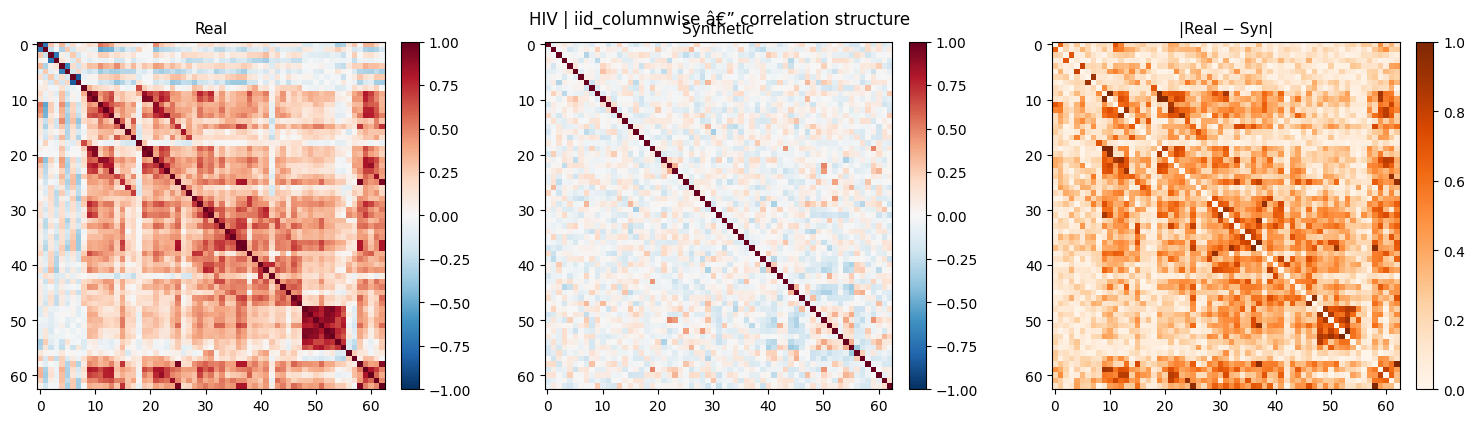

In [41]:
# Correlation heatmaps for HIV â€” one triptych per method
for method in METHODS:
    d = store[('HIV', method)]
    fig = plot_corr_matrices(
        d['X_real'], d['X_syn'],
        title=f'HIV | {method} â€” correlation structure',
    )
    plt.show()
    plt.close(fig)

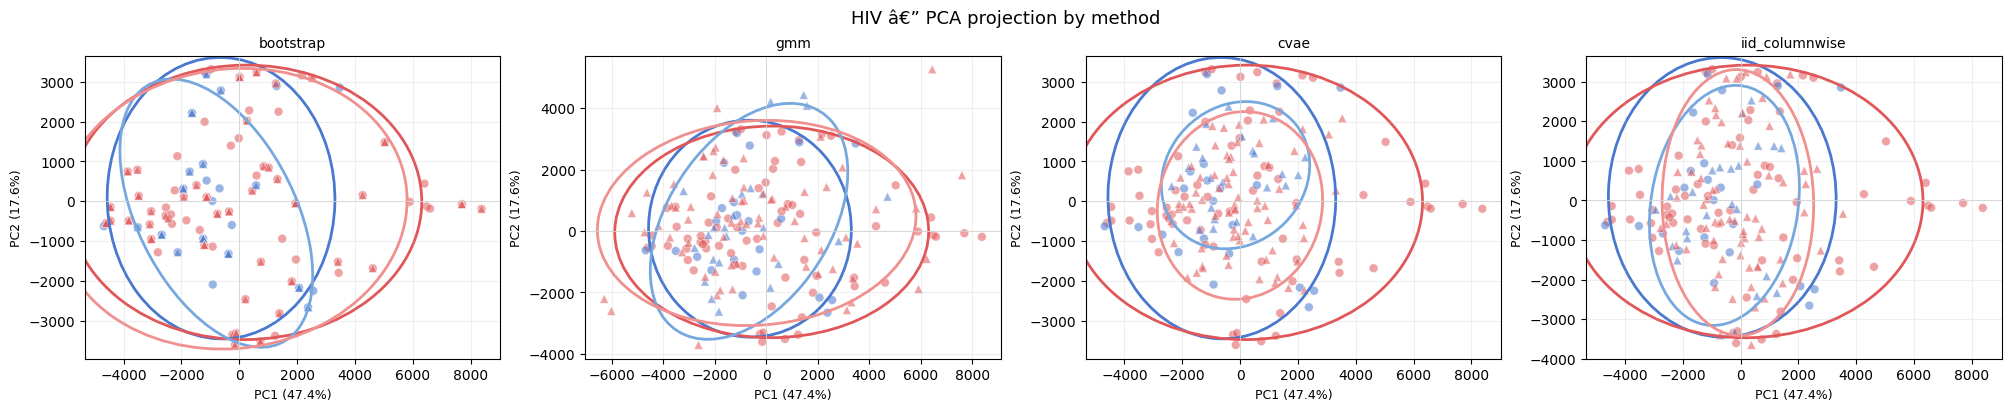

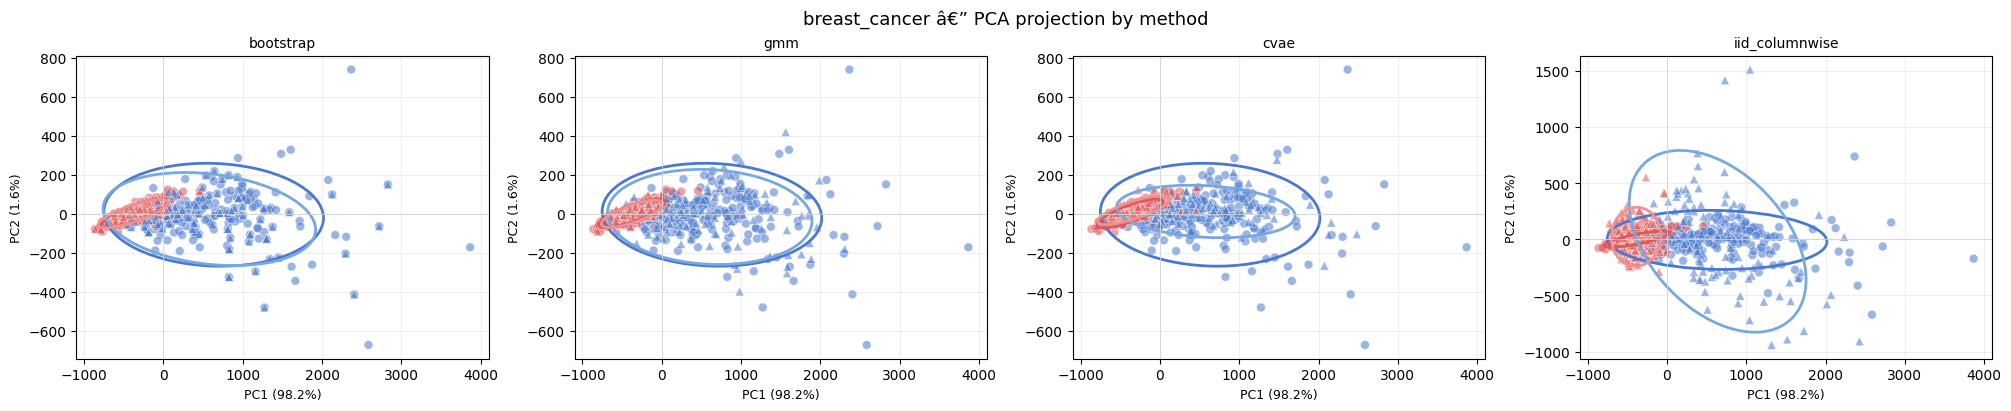

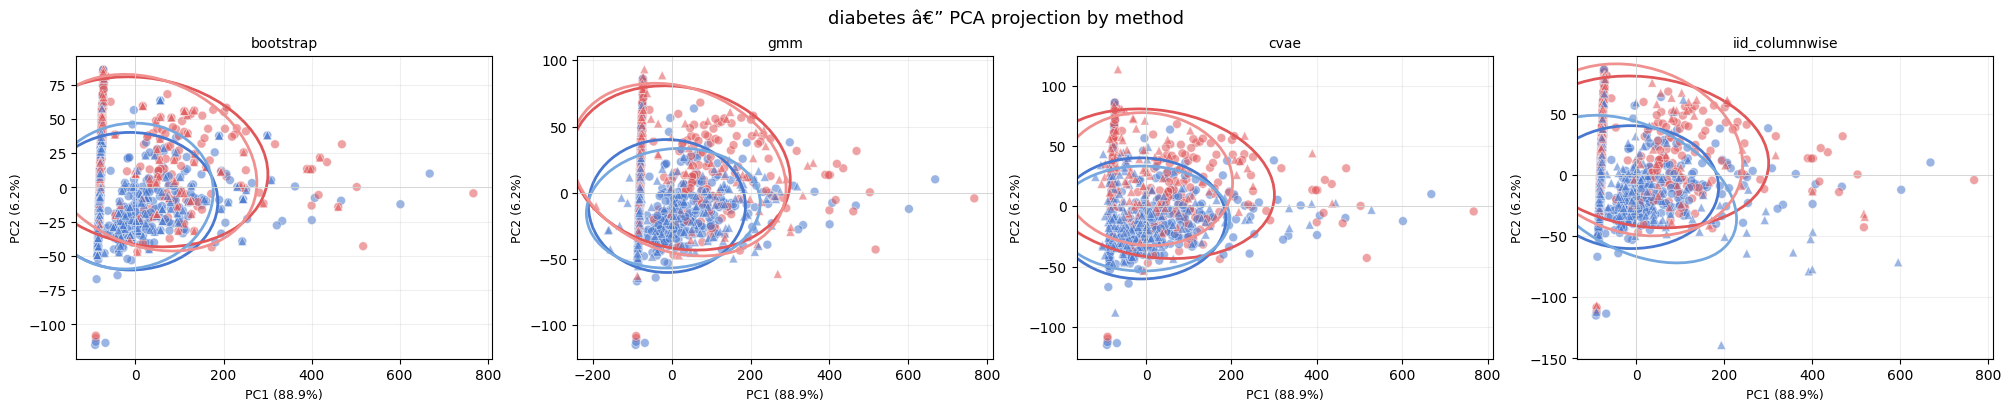

In [42]:
# PCA projections â€” all methods side by side for each dataset
for load_fn in DATASETS:
    ds = load_fn()['dataset']
    fig, axes = plt.subplots(1, len(METHODS), figsize=(5 * len(METHODS), 4),
                              constrained_layout=True)
    for ax, method in zip(axes, METHODS):
        d = store[(ds, method)]
        plot_pca_projection(d['X_real'], d['y_real'],
                            d['X_syn'], d['y_syn'],
                            ax=ax, title=method)
    fig.suptitle(f'{ds} â€” PCA projection by method', fontsize=13)
    plt.show()
    plt.close(fig)

---
## 6. Pillar 3 â€” Realism

**Question:** Do synthetic samples fall within the support of the real data?

Assessed via nearest-neighbour distances: for each synthetic sample, we measure its Euclidean distance to the nearest real sample, and compare the *scale* of those distances against the local density of the real data.

- **Ï„_real**: the **90th percentile** of real-to-real leave-one-out NN distances â€” the yardstick for "how far apart do real points typically sit?"
- **Ï„_syn**: the 90th percentile of syn-to-real NN distances â€” the typical distance from a synthetic point to the nearest real one.
- **Realism score**: `min(1, Ï„_real / Ï„_syn)`. Synthetic points whose typical NN scale matches or beats the real-to-real scale get full credit; sparser/more-extrapolating samples decay smoothly.

A 90th-percentile cutoff (rather than 95th) is intentionally stricter: fringe-of-cloud synthetic points should not score full credit.

This metric measures **plausibility** â€” whether generated points live in regions the real data actually occupies â€” not whether the generator copied training rows. Copying is a separate failure mode discussed below.

> **Note on bootstrap and copying.** Bootstrap resampling scores high on realism because its samples *are* real observations and therefore trivially plausible. This does not make bootstrap a good synthetic-data method: it provides no privacy, no novelty, and no augmentation â€” it is empirical reuse. The four-pillar profile makes this visible: bootstrap will show high realism and high utility, but the method's fundamental limitation (lack of generalization) should be evaluated separately from the DSRU axes, e.g. via a nearest-neighbour *identity* check or a duplicate-fraction audit.

In [43]:
real_cols = ['dataset', 'method', 'nn_dist_mean', 'nn_real_mean', 'nn_ratio']
display(df[real_cols].rename(columns={
    'nn_dist_mean': 'Syn-to-Real NN',
    'nn_real_mean': 'Real-to-Real NN',
    'nn_ratio': 'NN Ratio (syn/real)',
}).style.format(precision=3).background_gradient(
    subset=['Syn-to-Real NN'], cmap='RdYlGn_r', axis=0
))

,dataset,method,Syn-to-Real NN,Real-to-Real NN,NN Ratio (syn/real)
0,HIV,bootstrap,0.000,1711.817,0.000
1,HIV,gmm,2127.632,1711.817,1.243
2,HIV,cvae,1611.649,1711.817,0.941
3,HIV,iid_columnwise,2875.729,1711.817,1.680
4,breast_cancer,bootstrap,0.000,30.395,0.000
5,breast_cancer,gmm,29.776,30.395,0.980
6,breast_cancer,cvae,23.057,30.395,0.759
7,breast_cancer,iid_columnwise,124.585,30.395,4.099
8,diabetes,bootstrap,0.000,14.359,0.000
9,diabetes,gmm,19.434,14.359,1.353


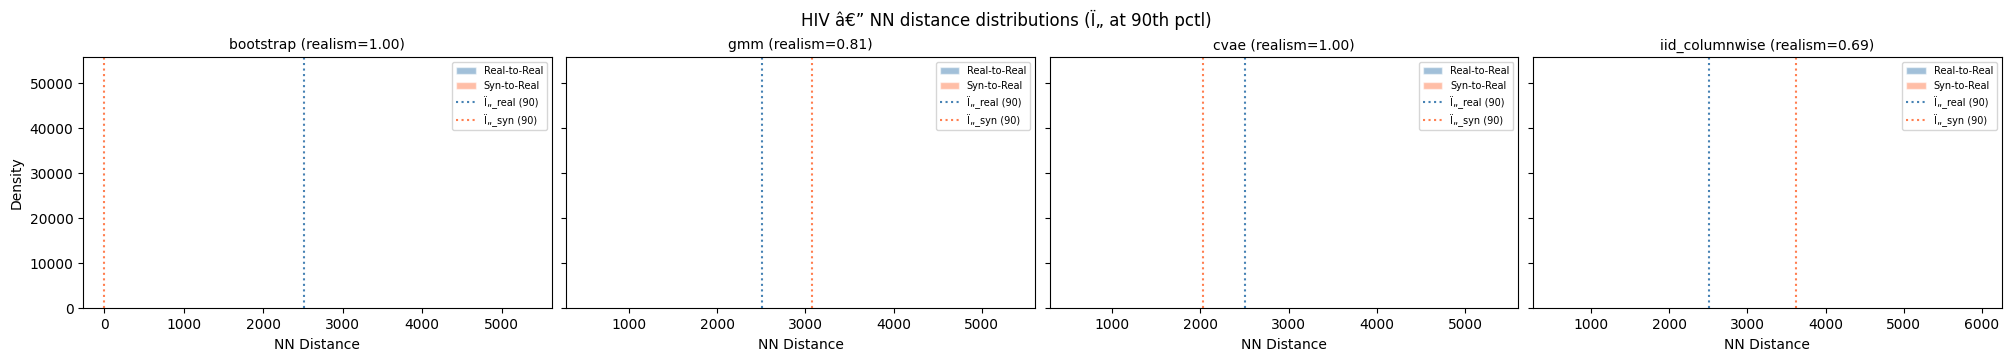

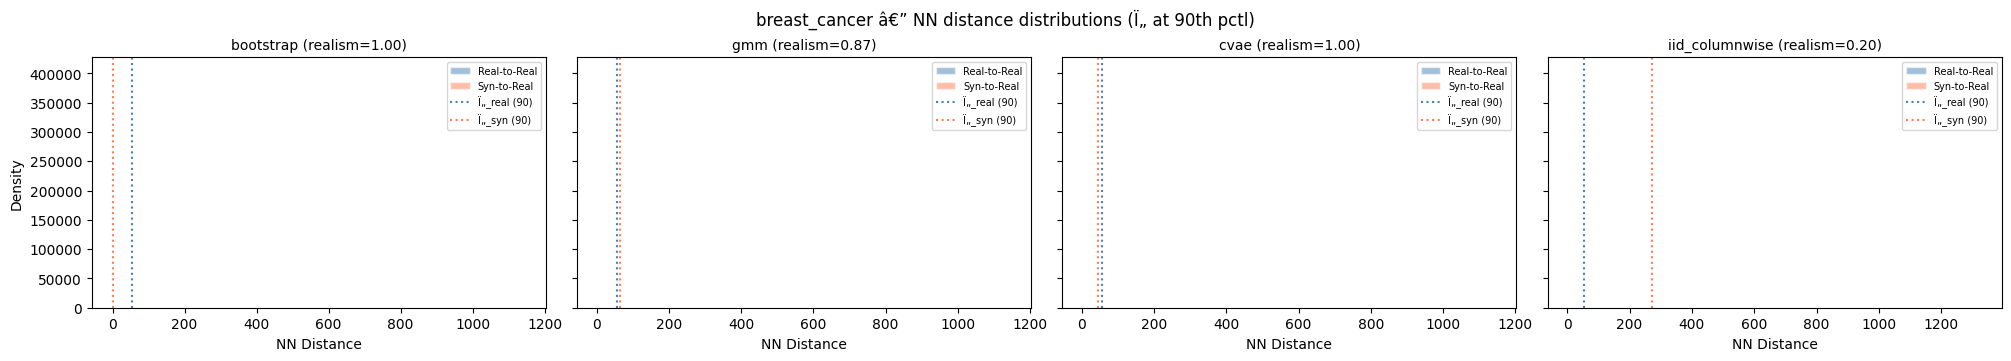

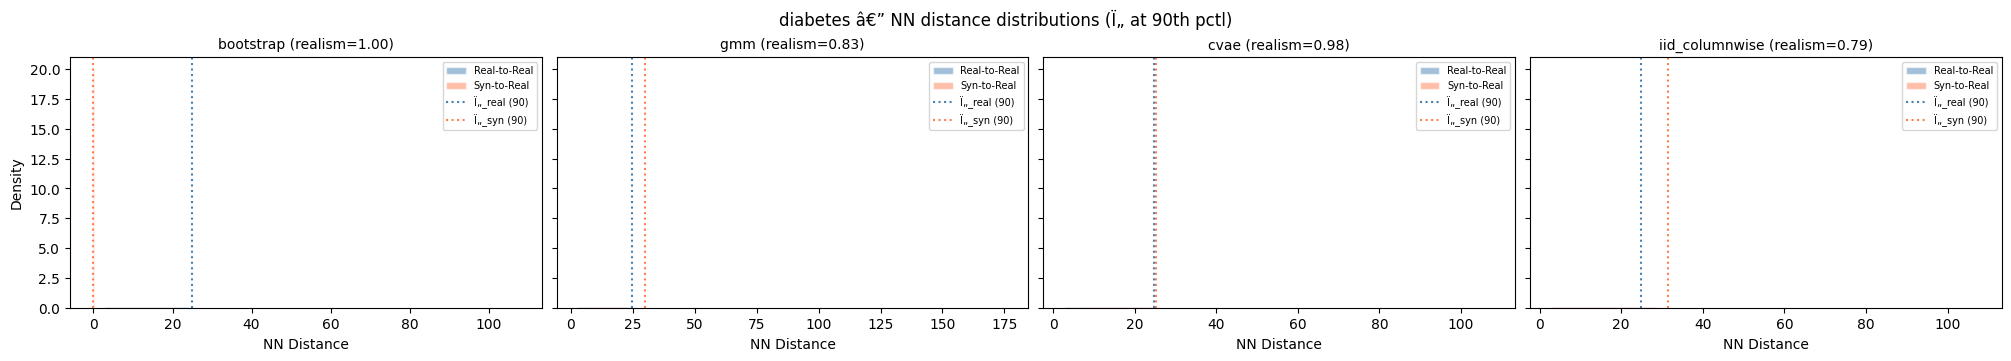

In [44]:
# NN distance distributions: synthetic-to-real vs real-to-real
for load_fn in DATASETS:
    ds = load_fn()['dataset']
    fig, axes = plt.subplots(1, len(METHODS), figsize=(5 * len(METHODS), 3.5),
                              constrained_layout=True, sharey=True)

    for ax, method in zip(axes, METHODS):
        d = store[(ds, method)]
        nn = nn_distances(d['X_real'], d['X_syn'])
        d_rr = nn['nn_dists_real']
        d_sr = nn['nn_dists_syn']
        tau_real = np.percentile(d_rr, 90)
        tau_syn  = np.percentile(d_sr, 90)
        ratio = min(1.0, tau_real / tau_syn) if tau_syn > 0 else 1.0

        ax.hist(d_rr, bins=20, alpha=0.5, color='steelblue',
                label='Real-to-Real', density=True, edgecolor='white')
        ax.hist(d_sr, bins=20, alpha=0.5, color='coral',
                label='Syn-to-Real', density=True, edgecolor='white')
        ax.axvline(tau_real, color='steelblue', ls=':', lw=1.5, label='Ï„_real (90)')
        ax.axvline(tau_syn,  color='coral',     ls=':', lw=1.5, label='Ï„_syn (90)')
        ax.set_title(f'{method} (realism={ratio:.2f})', fontsize=10)
        ax.set_xlabel('NN Distance')
        if ax == axes[0]:
            ax.set_ylabel('Density')
        ax.legend(fontsize=7)

    fig.suptitle(f'{ds} â€” NN distance distributions (Ï„ at 90th pctl)', fontsize=12)
    plt.show()
    plt.close(fig)

---
## 7. Pillar 4 — Utility

**Question:** Can the data still support meaningful downstream tasks?

Two layers of evidence are reported:

1. **Single-classifier descriptive view**: TSTR vs TRTR with a Random Forest. Easy to read and good for spotting catastrophic drops, but RF is robust enough that mediocre synthetic data still scores near-TRTR. This is why everything ends up huddled near 1.0.

2. **Multi-classifier radar score (§ 8)**: TSTR run with **four classifier families** — LR, KNN, RF, GBM — each with a different inductive bias. The radar's Utility axis is the mean per-family `(TSTR - baseline) / (1 - baseline)`. Different families surface different failure modes (LR fails on broken linear separability, KNN fails on broken local geometry), so methods stop huddling.

In [45]:
util_cols = ['dataset', 'method', 'tstr_f1', 'trtr_f1', 'utility_gap']
display(df[util_cols].rename(columns={
    'tstr_f1': 'TSTR F1',
    'trtr_f1': 'TRTR F1',
    'utility_gap': 'Utility Gap',
}).style.format(precision=3).background_gradient(
    subset=['Utility Gap'], cmap='RdYlGn_r', axis=0
))

,dataset,method,TSTR F1,TRTR F1,Utility Gap
0,HIV,bootstrap,0.993,0.964,-0.028
1,HIV,gmm,0.986,0.964,-0.021
2,HIV,cvae,0.977,0.964,-0.013
3,HIV,iid_columnwise,0.985,0.964,-0.021
4,breast_cancer,bootstrap,0.986,0.969,-0.017
5,breast_cancer,gmm,0.955,0.969,0.014
6,breast_cancer,cvae,0.974,0.969,-0.005
7,breast_cancer,iid_columnwise,0.959,0.969,0.011
8,diabetes,bootstrap,0.868,0.610,-0.258
9,diabetes,gmm,0.622,0.610,-0.012


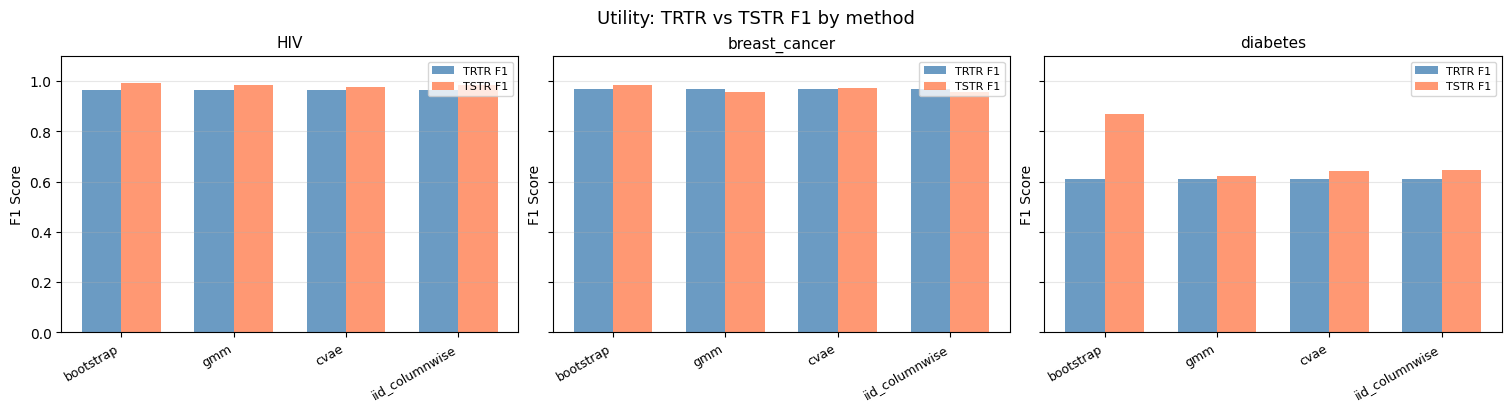

In [46]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5 * len(DATASETS), 4),
                          constrained_layout=True, sharey=True)

for ax, load_fn in zip(axes, DATASETS):
    ds = load_fn()['dataset']
    sub = df[df['dataset'] == ds]

    x = np.arange(len(METHODS))
    width = 0.35

    tstr_vals = [sub[sub['method'] == m]['tstr_f1'].values[0] for m in METHODS]
    trtr_vals = [sub[sub['method'] == m]['trtr_f1'].values[0] for m in METHODS]

    ax.bar(x - width/2, trtr_vals, width, label='TRTR F1', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, tstr_vals, width, label='TSTR F1', color='coral', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(METHODS, rotation=30, ha='right', fontsize=9)
    ax.set_title(ds, fontsize=11)
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Utility: TRTR vs TSTR F1 by method', fontsize=13)
plt.show()

### Multi-classifier utility

A single RF TSTR is too forgiving — Random Forests can soak up imperfect synthetic data and still hit near-TRTR F1. To stop methods huddling around 1.0 on the radar, we run TSTR + TRTR with **four classifier families that have very different inductive biases**:

| Family | What it tests |
|--------|----------------|
| **LR**  | Whether the right *linear* class boundary exists in the synthetic data |
| **KNN** | Whether *local geometry* is realistic — needs real-looking neighbours |
| **RF**  | Robust nonlinear ensemble — least sensitive to flaws (the lenient one) |
| **GBM** | Sequential nonlinear, more sensitive to subtle structural drift than RF |

A method that fools one classifier rarely fools all four. We aggregate per-family TSTR into the radar's Utility score using `(TSTR_f - baseline) / (1 - baseline)` per family, then take the **arithmetic mean** across families. Mean (rather than min) keeps the score smooth while still spreading methods out.

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score


def multi_classifier_utility(X_real, y_real, X_syn, y_syn, seed=42):
    """Run TSTR + TRTR for four classifier families with different inductive biases.

    Returns:
        dict[family] = {'tstr': float, 'trtr': float}
    """
    families = {
        'lr':  make_pipeline(StandardScaler(),
                             LogisticRegression(max_iter=1000, random_state=seed)),
        'knn': make_pipeline(StandardScaler(),
                             KNeighborsClassifier(n_neighbors=5)),
        'rf':  RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1),
        'gbm': GradientBoostingClassifier(n_estimators=100, random_state=seed),
    }

    n_splits = max(2, min(5, int((y_real == 0).sum()), int((y_real == 1).sum())))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    results = {}
    for name, base_clf in families.items():
        clf = clone(base_clf)
        clf.fit(X_syn, y_syn)
        tstr = f1_score(y_real, clf.predict(X_real),
                        average='binary', zero_division=0)

        trtr_scores = []
        for tr, te in skf.split(X_real, y_real):
            clf2 = clone(base_clf)
            clf2.fit(X_real[tr], y_real[tr])
            trtr_scores.append(f1_score(y_real[te], clf2.predict(X_real[te]),
                                         average='binary', zero_division=0))
        results[name] = {'tstr': float(tstr), 'trtr': float(np.mean(trtr_scores))}

    return results


# Compute multi-classifier utility for every (dataset, method)
multi_util_store = {}
multi_rows = []
for (ds, method), d in store.items():
    res = multi_classifier_utility(d['X_real'], d['y_real'],
                                    d['X_syn'],  d['y_syn'], seed=SEED)
    multi_util_store[(ds, method)] = res
    row = {'dataset': ds, 'method': method}
    for fam, scores in res.items():
        row[f'{fam}_tstr'] = scores['tstr']
        row[f'{fam}_trtr'] = scores['trtr']
    multi_rows.append(row)

multi_df = pd.DataFrame(multi_rows)

tstr_cols = [c for c in multi_df.columns if c.endswith('_tstr')]
display(multi_df[['dataset', 'method'] + tstr_cols].style.format(precision=3)
        .background_gradient(subset=tstr_cols, cmap='RdYlGn', axis=0))

,dataset,method,lr_tstr,knn_tstr,rf_tstr,gbm_tstr
0,HIV,bootstrap,1.000,0.978,0.993,0.993
1,HIV,gmm,0.978,0.978,0.986,0.915
2,HIV,cvae,0.962,0.971,0.993,0.935
3,HIV,iid_columnwise,0.977,0.752,0.978,0.924
4,breast_cancer,bootstrap,0.989,0.970,0.985,0.989
5,breast_cancer,gmm,0.983,0.958,0.958,0.954
6,breast_cancer,cvae,0.965,0.975,0.975,0.962
7,breast_cancer,iid_columnwise,0.949,0.946,0.960,0.959
8,diabetes,bootstrap,0.632,0.641,0.872,0.825
9,diabetes,gmm,0.637,0.571,0.622,0.626


---
## 8. Combined profile — DSRU Radar

Each method's position in the four-dimensional evaluation space, scored on [0, 1]:

| Pillar | Score = 1 | Score = 0 | Method |
|--------|-----------|-----------|--------|
| **Distribution** | Identical marginals | Maximally different | `1 - JSD₉₀ / ln(2)` — 90th-pctl of per-feature JSDs |
| **Structure** | Real vs syn indistinguishable to a classifier | Trivially separable | C2ST: `1 - 2·|AUC - 0.5|` (RF, 5-fold CV) |
| **Realism** | Synthetic NN-scale ≤ real NN-scale | Synthetic points far outside support | `min(1, τ_real(90) / τ_syn(90))` |
| **Utility** | All four classifiers hit perfect F1 | All four classifiers no better than majority class | Mean over LR/KNN/RF/GBM of `(TSTR_f - baseline) / (1 - baseline)` |

No arbitrary scaling constants. Every score has a defensible interpretation at both endpoints.

**Why structure is C2ST, not pairwise correlation.** Pairwise `Corr(Xi, Xj)` only captures linear bivariate structure. A method like CVAE can match every pairwise correlation almost perfectly and still get higher-order dependencies wrong — this is exactly what the ablation curves expose (you can drop the top features by RF importance and the synthetic-trained model barely loses AUC, because it isn't actually leaning on the right multivariate signal). A classifier two-sample test lets the discriminator use any feature combination, so it picks up the joint-structure damage that correlations wash out.

**Why utility is multi-classifier, not single RF TSTR.** A single RF is too forgiving — it can soak up imperfect synthetic data and still report near-TRTR F1. Combining four families with different inductive biases (LR / KNN / RF / GBM) means each method is tested against the failure modes it is most likely to hide. A method that fools RF rarely fools KNN; one that fools KNN rarely fools LR. Mean aggregation keeps the score smooth without zeroing out on a single bad family.

**Why utility uses `(1 - baseline)` and not `(TRTR - baseline)`.** Earlier versions normalised against the empirical TRTR ceiling, so a method matching a *weak* TRTR (e.g. diabetes ≈ 0.61) would score a perfect 1.0. The new denominator is the full possible range; matching TRTR is no longer treated as ideal — being close to F1 = 1 is.

Copying / empirical reuse is **not** penalised by any pillar — it is a separate failure mode. A method that simply resamples training rows will score well on all four axes, yet offer no privacy or novelty. This should be flagged via a dedicated identity/duplicate check, not smuggled into the realism score.

In [48]:
from scipy.stats import entropy as _entropy
from sklearn.neighbors import NearestNeighbors as _NN
from sklearn.ensemble import RandomForestClassifier as _RFC
from sklearn.model_selection import StratifiedKFold as _SKF
from sklearn.metrics import roc_auc_score as _auc


def dsru_distribution(X_real, X_syn, bins=30, q=0.90):
    """Distribution score via per-feature Jensen-Shannon divergence.

    Score in [0, 1]:
        1 = identical marginal distributions
        0 = maximally different marginals

    Uses the q-th quantile of per-feature JSDs (default 90th) — focuses on
    the worst features rather than averaging away outliers.
    """
    jsds = []
    for j in range(X_real.shape[1]):
        lo = min(X_real[:, j].min(), X_syn[:, j].min())
        hi = max(X_real[:, j].max(), X_syn[:, j].max())
        if hi == lo:
            jsds.append(0.0)
            continue
        edges = np.linspace(lo, hi, bins + 1)
        p, _ = np.histogram(X_real[:, j], bins=edges)
        qh, _ = np.histogram(X_syn[:, j], bins=edges)
        p = (p + 1e-10).astype(float); p /= p.sum()
        qh = (qh + 1e-10).astype(float); qh /= qh.sum()
        m = 0.5 * (p + qh)
        jsd = 0.5 * _entropy(p, m) + 0.5 * _entropy(qh, m)
        jsds.append(float(jsd))

    dist_bad = np.quantile(jsds, q)
    return float(np.clip(1.0 - dist_bad / np.log(2), 0.0, 1.0))


def dsru_structure(X_real, X_syn, seed=42, n_estimators=200):
    """Structure score: classifier two-sample test (C2ST).

    Train an RF to discriminate real from synthetic via stratified 5-fold CV.
    Map mean held-out AUC to a score:

        score = 1 - 2 * |AUC - 0.5|

    Endpoints:
        AUC = 0.5  → real and synthetic indistinguishable → score = 1
        AUC = 1.0  → trivially separable                  → score = 0

    A C2ST is sensitive to *any* joint deviation between the real and
    synthetic distributions — including higher-order dependencies that
    pairwise correlations cannot see.
    """
    n_real = X_real.shape[0]
    n_syn  = X_syn.shape[0]
    n      = min(n_real, n_syn)

    rng = np.random.default_rng(seed)
    idx_r = rng.choice(n_real, size=n, replace=False)
    idx_s = rng.choice(n_syn,  size=n, replace=False)

    X = np.vstack([X_real[idx_r], X_syn[idx_s]])
    y = np.concatenate([np.zeros(n, dtype=int), np.ones(n, dtype=int)])

    n_splits = max(2, min(5, n // 5))
    skf = _SKF(n_splits=n_splits, shuffle=True, random_state=seed)

    aucs = []
    for tr, te in skf.split(X, y):
        rf = _RFC(n_estimators=n_estimators, random_state=seed, n_jobs=-1)
        rf.fit(X[tr], y[tr])
        probs = rf.predict_proba(X[te])[:, 1]
        aucs.append(_auc(y[te], probs))

    auc = float(np.mean(aucs))
    auc_sep = max(auc, 1.0 - auc)
    score = 1.0 - 2.0 * (auc_sep - 0.5)
    return float(np.clip(score, 0.0, 1.0))


def dsru_realism(X_real, X_syn, q_real=0.90, q_syn=0.90):
    """Realism score: support proximity / plausibility.

    Score in [0, 1]:
        1 = synthetic NN-distance scale ≤ real-to-real NN-distance scale
        0 = synthetic points sit far outside the real data's local density

    Compares two scales of "neighbour distance":
        tau_real = q_real-th quantile of real-to-real LOO NN distances (90th)
        tau_syn  = q_syn-th  quantile of syn-to-real    NN distances (90th)

    The 90/90 cutoff is intentionally tighter than 95 — fringe-of-cloud
    synthetic points should not score full credit.

    Does NOT penalise copying — that is a separate failure mode.
    """
    nn_rr = _NN(n_neighbors=2, metric='euclidean')
    nn_rr.fit(X_real)
    d_rr = nn_rr.kneighbors(X_real)[0][:, 1]

    nn_sr = _NN(n_neighbors=1, metric='euclidean')
    nn_sr.fit(X_real)
    d_sr = nn_sr.kneighbors(X_syn)[0][:, 0]

    tau_real = np.quantile(d_rr, q_real)
    tau_syn  = np.quantile(d_sr, q_syn)

    if tau_syn <= 1e-12:
        return 1.0
    if tau_real <= 1e-12:
        return 0.0

    score = tau_real / tau_syn
    return float(np.clip(score, 0.0, 1.0))


def dsru_utility(util_dict, y_real):
    """Multi-classifier utility score.

    Aggregates TSTR across several classifier families (LR, KNN, RF, GBM).
    Each family contributes:

        s_f = (TSTR_f - baseline) / (1 - baseline)   clipped to [0, 1]

    Final score = arithmetic mean over families.

    Why mean (not min): mean keeps the score smooth and visually informative
    while still spreading methods out — different inductive biases catch
    different failure modes (LR catches broken linear separability, KNN
    catches broken local geometry, etc.). A method that fools one classifier
    rarely fools all four, and the mean reflects that.

    Baseline = majority-class F1 (positive class, binary).

    Args:
        util_dict: dict mapping family-name → {'tstr': float, 'trtr': float},
                   as returned by ``multi_classifier_utility``.
        y_real:    real-data labels (used to compute the majority baseline).
    """
    n1 = int((y_real == 1).sum())
    n0 = len(y_real) - n1
    baseline = 2.0 * n1 / (2.0 * n1 + n0) if n1 >= n0 else 0.0
    denom = 1.0 - baseline
    if denom < 1e-12:
        return 1.0

    per_family = []
    for fam, scores in util_dict.items():
        s = (scores['tstr'] - baseline) / denom
        per_family.append(float(np.clip(s, 0.0, 1.0)))

    if not per_family:
        return 0.0
    return float(np.mean(per_family))


print('DSRU scoring functions defined.')

DSRU scoring functions defined.


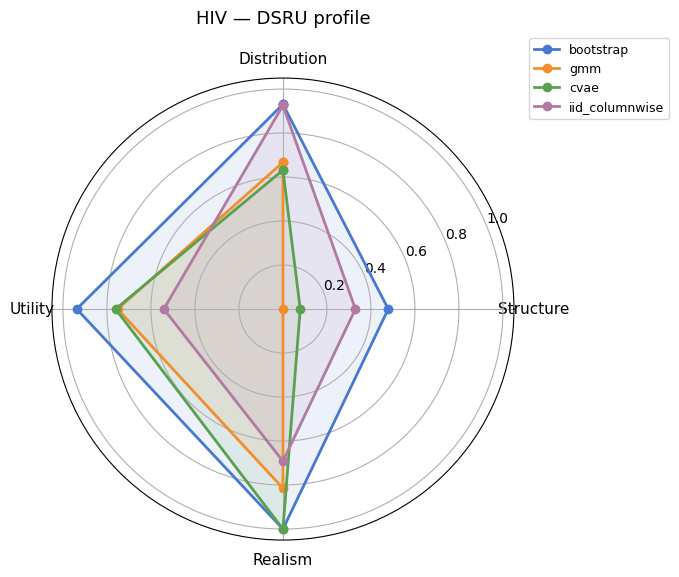

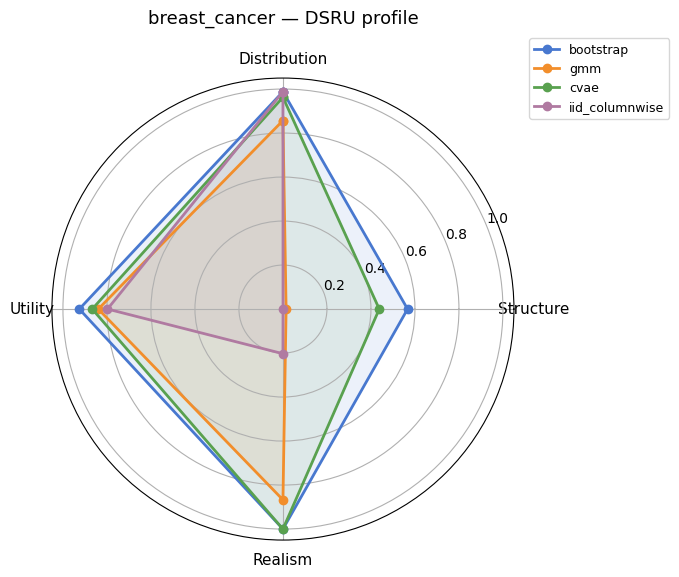

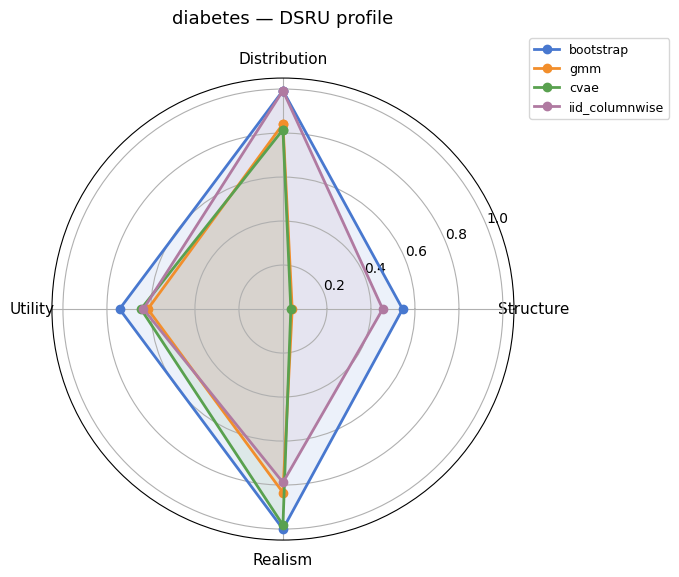

In [ ]:
# Axis order: Distribution (top), Structure (right), Realism (bottom), Utility (left)
pillar_names = ['Distribution', 'Structure', 'Realism', 'Utility']

# Angles: top=90, right=0, bottom=270, left=180
angles_deg = [90, 0, 270, 180]
angles = [np.radians(a) for a in angles_deg]
angles_closed = angles + angles[:1]

for load_fn in DATASETS:
    ds = load_fn()['dataset']
    sub = df[df['dataset'] == ds].copy()

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for method in METHODS:
        d = store[(ds, method)]
        X_r, y_r = d['X_real'], d['y_real']
        X_s = d['X_syn']

        # 1. Distribution: 90th-quantile per-feature JSD, bounded [0,1]
        dist_score = dsru_distribution(X_r, X_s)

        # 2. Structure: classifier two-sample test (RF AUC, 5-fold CV)
        struct_score = dsru_structure(X_r, X_s, seed=SEED)

        # 3. Realism: support proximity (tau_real(90) / tau_syn(90))
        real_score = dsru_realism(X_r, X_s)

        # 4. Utility: mean across LR/KNN/RF/GBM of (TSTR - baseline)/(1 - baseline)
        util_score = dsru_utility(multi_util_store[(ds, method)], y_r)

        vals = [dist_score, struct_score, real_score, util_score]
        vals_closed = vals + vals[:1]

        color = METHOD_COLORS.get(method, 'gray')
        ax.plot(angles_closed, vals_closed, 'o-', label=method, color=color, linewidth=2, markersize=6)
        ax.fill(angles_closed, vals_closed, alpha=0.1, color=color)

    ax.set_thetagrids(angles_deg, pillar_names, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{ds} — A better way to think about “good” data', fontsize=13, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
    plt.show()
    plt.close(fig)

---
## 9. Summary table

All four pillars side by side for easy comparison.

In [50]:
summary = df[['dataset', 'method',
              'kld_mean', 'prop_significant',
              'corr_diff',
              'nn_ratio',
              'tstr_f1', 'utility_gap']].copy()

summary = summary.rename(columns={
    'kld_mean': 'KLD Mean',
    'prop_significant': 'Prop Sig',
    'corr_diff': 'Corr Diff',
    'nn_ratio': 'NN Ratio',
    'tstr_f1': 'TSTR F1',
    'utility_gap': 'Util Gap',
})

display(summary.style.format(precision=3).background_gradient(
    subset=['KLD Mean', 'Prop Sig', 'Corr Diff', 'NN Ratio', 'Util Gap'],
    cmap='RdYlGn_r', axis=0
).background_gradient(
    subset=['TSTR F1'], cmap='RdYlGn', axis=0
))

,dataset,method,KLD Mean,Prop Sig,Corr Diff,NN Ratio,TSTR F1,Util Gap
0,HIV,bootstrap,0.756,0.000,0.072,0.000,0.993,-0.028
1,HIV,gmm,1.182,0.032,0.079,1.243,0.986,-0.021
2,HIV,cvae,2.752,0.317,0.120,0.941,0.977,-0.013
3,HIV,iid_columnwise,0.814,0.000,0.296,1.680,0.985,-0.021
4,breast_cancer,bootstrap,0.088,0.000,0.029,0.000,0.986,-0.017
5,breast_cancer,gmm,0.276,0.000,0.076,0.980,0.955,0.014
6,breast_cancer,cvae,0.344,0.167,0.065,0.759,0.974,-0.005
7,breast_cancer,iid_columnwise,0.083,0.000,0.200,4.099,0.959,0.011
8,diabetes,bootstrap,0.051,0.000,0.023,0.000,0.868,-0.258
9,diabetes,gmm,0.455,0.125,0.027,1.353,0.622,-0.012


In [51]:
df.to_csv('../results/four_pillars.csv', index=False)
print('Saved: ../results/four_pillars.csv')

Saved: ../results/four_pillars.csv
